In [2]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.data_loader import load_prices

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

# Load prices
prices = load_prices()

# Compute signals inline (we'll refactor into src/signals.py at the end)
sma_200 = prices.rolling(window=200).mean()
signal_200d = (prices > sma_200)

sma_fast = prices.rolling(window=10).mean()
sma_slow = prices.rolling(window=30).mean()
signal_crossover = (sma_fast > sma_slow)

print(f"Prices:    {prices.shape}")
print(f"200d sig:  {signal_200d.shape}")
print(f"10/30 sig: {signal_crossover.shape}")

Prices:    (6632, 7)
200d sig:  (6632, 7)
10/30 sig: (6632, 7)


In [3]:
# Get the first trading day of each month
month_starts = prices.groupby(prices.index.to_period('M')).head(1).index

print(f"Number of rebalance dates: {len(month_starts)}")
print(f"\nFirst 5:")
print(month_starts[:5])
print(f"\nLast 5:")
print(month_starts[-5:])

Number of rebalance dates: 317

First 5:
DatetimeIndex(['2000-01-03', '2000-02-01', '2000-03-01', '2000-04-03', '2000-05-01'], dtype='datetime64[ms]', name='Date', freq=None)

Last 5:
DatetimeIndex(['2026-01-02', '2026-02-02', '2026-03-02', '2026-04-01', '2026-05-01'], dtype='datetime64[ms]', name='Date', freq=None)


In [4]:
signal_lagged = signal_200d.shift(1)

rebalance_signals = signal_lagged.loc[month_starts]

print(f"Rebalance signals shape: {rebalance_signals.shape}")
print(f"\nFirst valid rebalance signals:")
print(rebalance_signals.dropna(how='all').head(3))
print(f"\nMost recent rebalance signals:")
print(rebalance_signals.tail(3))

Rebalance signals shape: (317, 7)

First valid rebalance signals:
Ticker        AGG    BIL    DBC    EFA    GLD    SPY    VNQ
Date                                                       
2000-02-01  False  False  False  False  False  False  False
2000-03-01  False  False  False  False  False  False  False
2000-04-03  False  False  False  False  False  False  False

Most recent rebalance signals:
Ticker       AGG   BIL   DBC   EFA   GLD    SPY    VNQ
Date                                                  
2026-03-02  True  True  True  True  True   True   True
2026-04-01  True  True  True  True  True  False  False
2026-05-01  True  True  True  True  True   True   True


In [7]:
RISK_ASSETS = ["SPY", "EFA", "AGG", "GLD", "DBC", "VNQ"]
N_RISK = len(RISK_ASSETS)
ASSET_WEIGHT = 1.0 / N_RISK  # 0.1667 per asset slot

# Restrict to risk assets and coerce to a clean boolean (NaN → False)
risk_signals = rebalance_signals[RISK_ASSETS].fillna(False).astype(bool)

# Build weights DataFrame: same shape as risk_signals, plus a BIL column
weights = pd.DataFrame(0.0, index=risk_signals.index, columns=prices.columns)

# Each risk asset: ASSET_WEIGHT when "on", 0 when "off"
for asset in RISK_ASSETS:
    weights[asset] = risk_signals[asset].astype(float) * ASSET_WEIGHT

# BIL absorbs the off slots: count "off" assets per row, multiply by ASSET_WEIGHT
n_off = (~risk_signals).sum(axis=1)
weights["BIL"] = n_off * ASSET_WEIGHT

# Verify rows sum to 1.0
row_sums = weights.sum(axis=1)
print("Most recent month's weights:")
print(weights.iloc[-1])
print(f"\nWeights sum to 1.0 for recent months?")
print(row_sums.tail(5))

Most recent month's weights:
Ticker
AGG    0.166667
BIL    0.000000
DBC    0.166667
EFA    0.166667
GLD    0.166667
SPY    0.166667
VNQ    0.166667
Name: 2026-05-01 00:00:00, dtype: float64

Weights sum to 1.0 for recent months?
Date
2026-01-02    1.0
2026-02-02    1.0
2026-03-02    1.0
2026-04-01    1.0
2026-05-01    1.0
dtype: float64


In [8]:
# What did the daily signals look like at month-end April vs mid-May?
print("Signal at April 30, 2026 (used for May 1 rebalance):")
print(signal_200d.loc["2026-04-30"])
print("\nSignal at May 15, 2026 (most recent):")
print(signal_200d.loc["2026-05-15"])

Signal at April 30, 2026 (used for May 1 rebalance):
Ticker
AGG    True
BIL    True
DBC    True
EFA    True
GLD    True
SPY    True
VNQ    True
Name: 2026-04-30 00:00:00, dtype: bool

Signal at May 15, 2026 (most recent):
Ticker
AGG    False
BIL     True
DBC     True
EFA     True
GLD     True
SPY     True
VNQ     True
Name: 2026-05-15 00:00:00, dtype: bool


In [9]:
# Reindex weights to every trading day, forward-filling between rebalances
daily_weights = weights.reindex(prices.index, method='ffill')

print(f"Daily weights shape: {daily_weights.shape}")
print(f"\nWeights around a rebalance date (April 30 to May 5):")
print(daily_weights.loc["2026-04-30":"2026-05-05"])

Daily weights shape: (6632, 7)

Weights around a rebalance date (April 30 to May 5):
Ticker           AGG       BIL       DBC       EFA       GLD       SPY       VNQ
Date                                                                            
2026-04-30  0.166667  0.333333  0.166667  0.166667  0.166667  0.000000  0.000000
2026-05-01  0.166667  0.000000  0.166667  0.166667  0.166667  0.166667  0.166667
2026-05-04  0.166667  0.000000  0.166667  0.166667  0.166667  0.166667  0.166667
2026-05-05  0.166667  0.000000  0.166667  0.166667  0.166667  0.166667  0.166667


In [10]:
asset_returns = prices.pct_change()

# Portfolio return = sum across assets of (weight × return), day by day
# But: yesterday's weight applies to today's return (because you entered the position yesterday)
portfolio_returns = (daily_weights.shift(1) * asset_returns).sum(axis=1)

print(f"Portfolio returns shape: {portfolio_returns.shape}")
print(f"\nMost recent 10 days of portfolio returns:")
print(portfolio_returns.tail(10))
print(f"\nReturns summary (full sample, daily):")
print(portfolio_returns.describe())

Portfolio returns shape: (6632,)

Most recent 10 days of portfolio returns:
Date
2026-05-04   -0.004982
2026-05-05    0.005122
2026-05-06    0.009633
2026-05-07   -0.004670
2026-05-08    0.004977
2026-05-11    0.004229
2026-05-12    0.001016
2026-05-13   -0.001882
2026-05-14   -0.002762
2026-05-15   -0.011977
dtype: float64

Returns summary (full sample, daily):
count    6632.000000
mean        0.000214
std         0.004460
min        -0.038346
25%        -0.001494
50%         0.000000
75%         0.002259
max         0.038240
dtype: float64


In [11]:
# Build cumulative equity curve: $1 invested, compounded daily
equity_curve = (1 + portfolio_returns.fillna(0)).cumprod()

# Also compute a benchmark: 60/40 (SPY/AGG) buy-and-hold for comparison
spy_returns = prices["SPY"].pct_change()
agg_returns = prices["AGG"].pct_change()
benchmark_returns = 0.6 * spy_returns + 0.4 * agg_returns
benchmark_equity = (1 + benchmark_returns.fillna(0)).cumprod()

# Quick summary
print("Strategy:")
print(f"  Final equity: ${equity_curve.iloc[-1]:.2f}")
print(f"  Total return: {(equity_curve.iloc[-1] - 1):.1%}")
print(f"  CAGR (approx): {(equity_curve.iloc[-1]**(1/26.4) - 1):.1%}")

print("\nBenchmark 60/40:")
print(f"  Final equity: ${benchmark_equity.iloc[-1]:.2f}")
print(f"  Total return: {(benchmark_equity.iloc[-1] - 1):.1%}")
print(f"  CAGR (approx): {(benchmark_equity.iloc[-1]**(1/26.4) - 1):.1%}")

Strategy:
  Final equity: $3.87
  Total return: 287.3%
  CAGR (approx): 5.3%

Benchmark 60/40:
  Final equity: $6.16
  Total return: 515.8%
  CAGR (approx): 7.1%


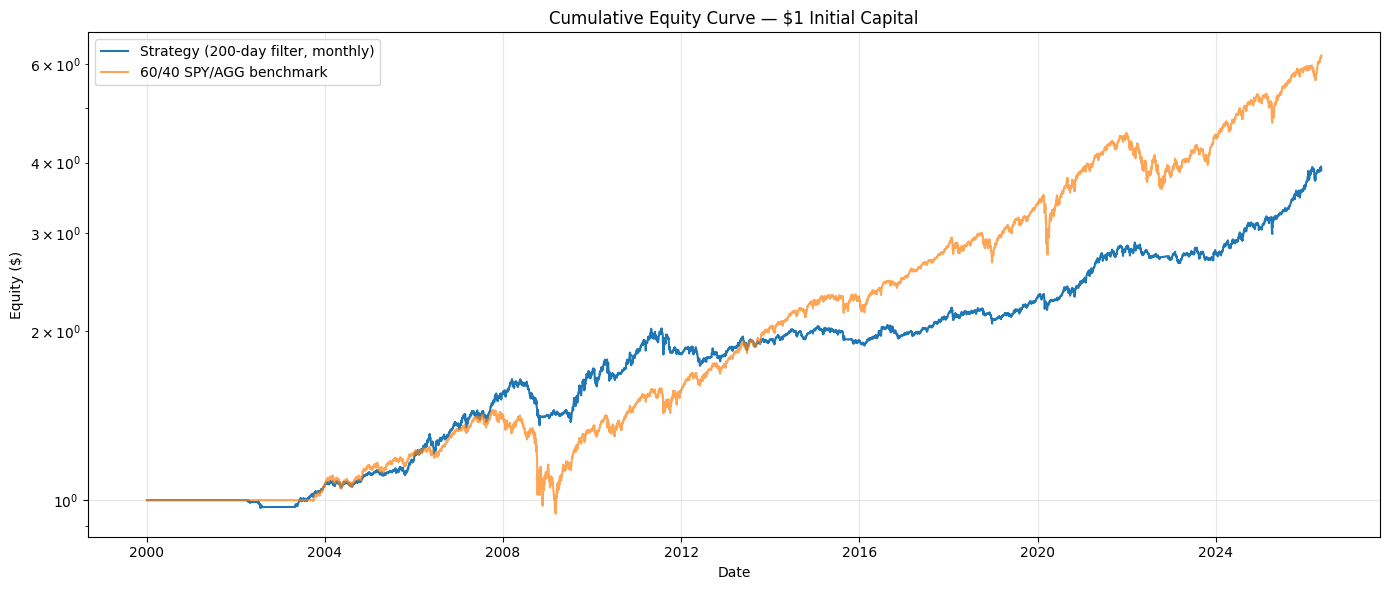

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(equity_curve.index, equity_curve, label="Strategy (200-day filter, monthly)", linewidth=1.5)
ax.plot(benchmark_equity.index, benchmark_equity, label="60/40 SPY/AGG benchmark", linewidth=1.5, alpha=0.7)

ax.set_title("Cumulative Equity Curve — $1 Initial Capital")
ax.set_xlabel("Date")
ax.set_ylabel("Equity ($)")
ax.set_yscale("log")  # log scale makes long-run growth comparable
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
import numpy as np

def annualized_return(returns, periods_per_year=252):
    """Geometric annualized return from a daily return series."""
    total_return = (1 + returns.fillna(0)).prod()
    n_periods = len(returns.dropna())
    return total_return ** (periods_per_year / n_periods) - 1

def annualized_vol(returns, periods_per_year=252):
    return returns.std() * np.sqrt(periods_per_year)

def sharpe_ratio(returns, periods_per_year=252, rf=0.0):
    """Sharpe ratio assuming 0% risk-free rate."""
    excess = returns - rf / periods_per_year
    return (excess.mean() / excess.std()) * np.sqrt(periods_per_year)

def max_drawdown(returns):
    """Maximum peak-to-trough drawdown from cumulative returns."""
    equity = (1 + returns.fillna(0)).cumprod()
    running_max = equity.cummax()
    drawdown = (equity - running_max) / running_max
    return drawdown.min()

def calmar_ratio(returns):
    """CAGR divided by absolute max drawdown."""
    return annualized_return(returns) / abs(max_drawdown(returns))

# Compute for both
comparison = pd.DataFrame({
    "Strategy":  [
        annualized_return(portfolio_returns),
        annualized_vol(portfolio_returns),
        sharpe_ratio(portfolio_returns),
        max_drawdown(portfolio_returns),
        calmar_ratio(portfolio_returns),
    ],
    "60/40 Benchmark":  [
        annualized_return(benchmark_returns),
        annualized_vol(benchmark_returns),
        sharpe_ratio(benchmark_returns),
        max_drawdown(benchmark_returns),
        calmar_ratio(benchmark_returns),
    ],
}, index=["CAGR", "Vol (ann.)", "Sharpe", "Max DD", "Calmar"])

print(comparison.to_string(float_format='{:.3f}'.format))

            Strategy  60/40 Benchmark
CAGR           0.053            0.084
Vol (ann.)     0.071            0.114
Sharpe         0.762            0.766
Max DD        -0.173           -0.347
Calmar         0.306            0.241


In [14]:
# Turnover = sum of absolute weight changes between consecutive rebalances, divided by 2
# (dividing by 2 avoids double-counting: every dollar sold from one asset is bought into another)
weight_changes = weights.diff().abs().sum(axis=1)
turnover = weight_changes / 2

print(f"Monthly turnover summary:")
print(turnover.describe().to_string(float_format='{:.3f}'.format))
print(f"\nFirst-rebalance turnover (initial portfolio build):")
print(f"  {turnover.iloc[0]:.3f}")
print(f"\nAverage turnover excluding the first rebalance:")
print(f"  {turnover.iloc[1:].mean():.3f}")
print(f"\nAnnualized turnover: {turnover.iloc[1:].mean() * 12:.1%}")

Monthly turnover summary:
count   317.000
mean      0.109
std       0.136
min       0.000
25%       0.000
50%       0.000
75%       0.167
max       0.667

First-rebalance turnover (initial portfolio build):
  0.000

Average turnover excluding the first rebalance:
  0.110

Annualized turnover: 131.6%


In [15]:
COST_PER_RT = 0.0005  # 5bp round-trip per dollar of turnover

rebalance_costs = turnover * COST_PER_RT
daily_costs = rebalance_costs.reindex(prices.index, fill_value=0)
portfolio_returns_net = portfolio_returns - daily_costs

def summarize(returns, name):
    return pd.Series({
        "CAGR":       annualized_return(returns),
        "Vol (ann.)": annualized_vol(returns),
        "Sharpe":     sharpe_ratio(returns),
        "Max DD":     max_drawdown(returns),
        "Calmar":     calmar_ratio(returns),
    }, name=name)

comparison_with_costs = pd.DataFrame({
    "Strategy (gross)": summarize(portfolio_returns, "gross").values,
    "Strategy (net)":   summarize(portfolio_returns_net, "net").values,
    "60/40 Benchmark":  summarize(benchmark_returns, "bench").values,
}, index=["CAGR", "Vol (ann.)", "Sharpe", "Max DD", "Calmar"])

print(comparison_with_costs.to_string(float_format='{:.3f}'.format))

            Strategy (gross)  Strategy (net)  60/40 Benchmark
CAGR                   0.053           0.052            0.084
Vol (ann.)             0.071           0.071            0.114
Sharpe                 0.762           0.753            0.766
Max DD                -0.173          -0.173           -0.347
Calmar                 0.306           0.301            0.241


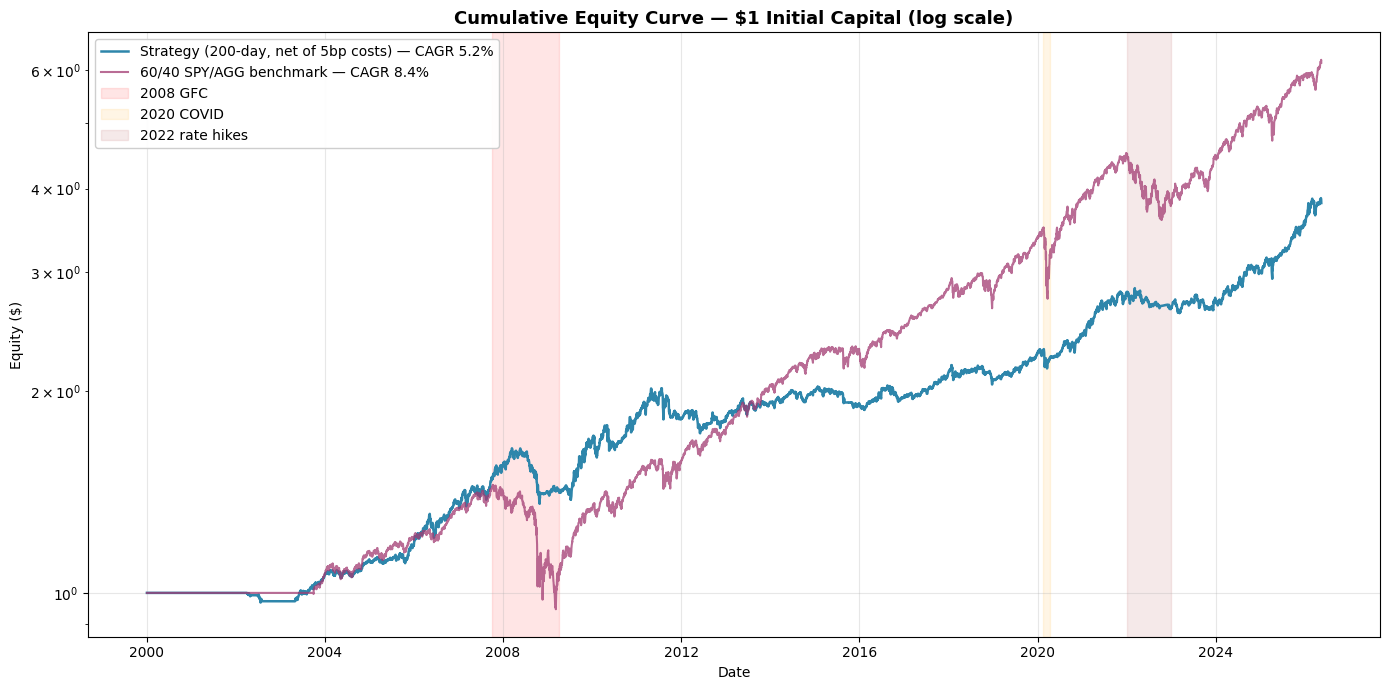

Chart saved to ../results/equity_curve.png


In [16]:
# Use net-of-cost strategy returns going forward
strategy_returns = portfolio_returns_net

# Compute equity curves
equity_strategy = (1 + strategy_returns.fillna(0)).cumprod()
equity_benchmark = (1 + benchmark_returns.fillna(0)).cumprod()

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(equity_strategy.index, equity_strategy,
        label=f"Strategy (200-day, net of 5bp costs) — CAGR {annualized_return(strategy_returns):.1%}",
        linewidth=1.8, color="#2E86AB")
ax.plot(equity_benchmark.index, equity_benchmark,
        label=f"60/40 SPY/AGG benchmark — CAGR {annualized_return(benchmark_returns):.1%}",
        linewidth=1.5, color="#A23B72", alpha=0.75)

# Shade major stress periods so the eye knows where to look
ax.axvspan("2007-10-01", "2009-03-31", alpha=0.10, color="red", label="2008 GFC")
ax.axvspan("2020-02-15", "2020-04-15", alpha=0.10, color="orange", label="2020 COVID")
ax.axvspan("2022-01-01", "2022-12-31", alpha=0.10, color="brown", label="2022 rate hikes")

ax.set_title("Cumulative Equity Curve — $1 Initial Capital (log scale)",
             fontsize=13, weight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Equity ($)")
ax.set_yscale("log")
ax.legend(loc="upper left", framealpha=0.95)
ax.grid(alpha=0.3)

plt.tight_layout()

# Save for the README
results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(results_dir / "equity_curve.png", dpi=150, bbox_inches="tight")

plt.show()
print(f"Chart saved to {results_dir / 'equity_curve.png'}")

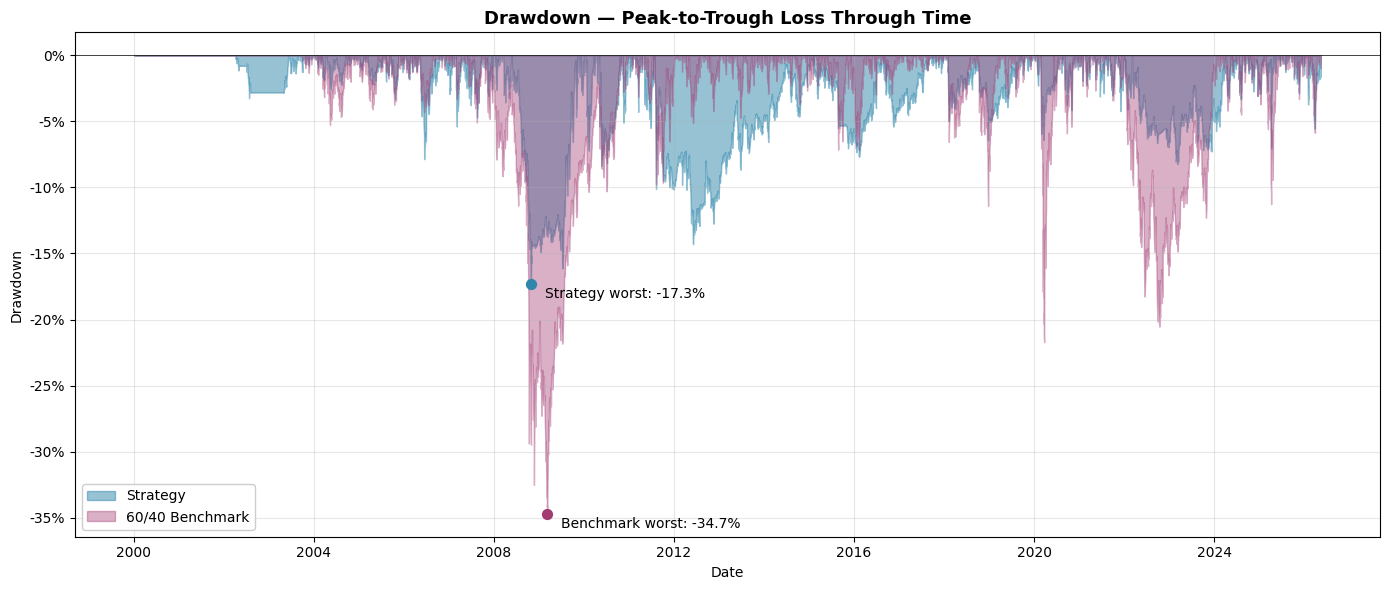

Chart saved to ../results/drawdown.png


In [17]:
def drawdown_series(returns):
    """Daily drawdown as a percentage from peak."""
    equity = (1 + returns.fillna(0)).cumprod()
    running_max = equity.cummax()
    return (equity - running_max) / running_max

dd_strategy = drawdown_series(strategy_returns)
dd_benchmark = drawdown_series(benchmark_returns)

fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(dd_strategy.index, dd_strategy, 0,
                color="#2E86AB", alpha=0.5, label="Strategy")
ax.fill_between(dd_benchmark.index, dd_benchmark, 0,
                color="#A23B72", alpha=0.4, label="60/40 Benchmark")

# Mark the worst-drawdown points
strat_min_date = dd_strategy.idxmin()
bench_min_date = dd_benchmark.idxmin()
ax.scatter([strat_min_date], [dd_strategy.min()], color="#2E86AB", zorder=5, s=50)
ax.scatter([bench_min_date], [dd_benchmark.min()], color="#A23B72", zorder=5, s=50)

ax.annotate(f"Strategy worst: {dd_strategy.min():.1%}",
            xy=(strat_min_date, dd_strategy.min()),
            xytext=(10, -10), textcoords="offset points", fontsize=10)
ax.annotate(f"Benchmark worst: {dd_benchmark.min():.1%}",
            xy=(bench_min_date, dd_benchmark.min()),
            xytext=(10, -10), textcoords="offset points", fontsize=10)

ax.set_title("Drawdown — Peak-to-Trough Loss Through Time",
             fontsize=13, weight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend(loc="lower left", framealpha=0.95)
ax.grid(alpha=0.3)
ax.axhline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.savefig(results_dir / "drawdown.png", dpi=150, bbox_inches="tight")

plt.show()
print(f"Chart saved to {results_dir / 'drawdown.png'}")

In [18]:
def drawdown_details(returns, name):
    equity = (1 + returns.fillna(0)).cumprod()
    running_max = equity.cummax()
    dd = (equity - running_max) / running_max

    worst_idx = dd.idxmin()
    worst_value = dd.min()

    # Find peak before the trough and recovery date after
    peak_idx = equity.loc[:worst_idx].idxmax()
    after_trough = equity.loc[worst_idx:]
    recovery_mask = after_trough >= equity.loc[peak_idx]
    recovery_idx = after_trough[recovery_mask].index.min() if recovery_mask.any() else pd.NaT

    underwater_days = (dd < 0).sum()
    pct_underwater = underwater_days / len(dd)

    print(f"\n{name}:")
    print(f"  Worst drawdown:    {worst_value:.1%}")
    print(f"  Peak date:         {peak_idx.date()}")
    print(f"  Trough date:       {worst_idx.date()}")
    print(f"  Recovery date:     {recovery_idx.date() if pd.notna(recovery_idx) else 'never (still in DD)'}")
    print(f"  Time underwater:   {pct_underwater:.1%} of all days")

drawdown_details(strategy_returns, "Strategy (200-day, net)")
drawdown_details(benchmark_returns, "60/40 Benchmark")


Strategy (200-day, net):
  Worst drawdown:    -17.3%
  Peak date:         2008-03-14
  Trough date:       2008-10-27
  Recovery date:     2009-11-11
  Time underwater:   83.9% of all days

60/40 Benchmark:
  Worst drawdown:    -34.7%
  Peak date:         2007-10-09
  Trough date:       2009-03-09
  Recovery date:     2010-11-02
  Time underwater:   73.0% of all days


In [19]:
def avg_drawdown_depth(returns):
    equity = (1 + returns.fillna(0)).cumprod()
    running_max = equity.cummax()
    dd = (equity - running_max) / running_max
    # Only average over days when underwater
    return dd[dd < 0].mean()

print(f"Average drawdown depth (underwater days only):")
print(f"  Strategy:  {avg_drawdown_depth(strategy_returns):.2%}")
print(f"  Benchmark: {avg_drawdown_depth(benchmark_returns):.2%}")

Average drawdown depth (underwater days only):
  Strategy:  -3.48%
  Benchmark: -4.12%


In [20]:
def run_backtest(
    prices: pd.DataFrame,
    signal: pd.DataFrame,
    risk_assets: list,
    defensive: str = "BIL",
    cost_rt: float = 0.0005,
):
    """
    Run a monthly-rebalanced trend-following backtest.
    
    Parameters
    ----------
    prices : DataFrame
        Daily prices, rows=dates, columns=tickers.
    signal : DataFrame
        Daily boolean signals, same shape as prices. True = "on" (hold the asset).
    risk_assets : list of str
        Tickers that go through the trend filter.
    defensive : str
        Ticker that absorbs the "off" sleeve.
    cost_rt : float
        Round-trip transaction cost as a decimal (0.0005 = 5bp).
    
    Returns
    -------
    dict with keys: 'returns_gross', 'returns_net', 'weights', 'turnover'
    """
    n_risk = len(risk_assets)
    asset_weight = 1.0 / n_risk
    
    # Monthly rebalance dates
    month_starts = prices.groupby(prices.index.to_period('M')).head(1).index
    
    # Lagged signal at rebalance dates (look-ahead protection)
    signal_lagged = signal.shift(1)
    rebalance_signals = signal_lagged.loc[month_starts]
    risk_signals = rebalance_signals[risk_assets].fillna(False).astype(bool)
    
    # Build weights
    weights = pd.DataFrame(0.0, index=risk_signals.index, columns=prices.columns)
    for asset in risk_assets:
        weights[asset] = risk_signals[asset].astype(float) * asset_weight
    weights[defensive] = (~risk_signals).sum(axis=1) * asset_weight
    
    # Daily weights via forward-fill
    daily_weights = weights.reindex(prices.index, method='ffill')
    
    # Daily portfolio returns
    asset_returns = prices.pct_change()
    returns_gross = (daily_weights.shift(1) * asset_returns).sum(axis=1)
    
    # Turnover and costs
    turnover = weights.diff().abs().sum(axis=1) / 2
    daily_costs = (turnover * cost_rt).reindex(prices.index, fill_value=0)
    returns_net = returns_gross - daily_costs
    
    return {
        "returns_gross": returns_gross,
        "returns_net":   returns_net,
        "weights":       weights,
        "turnover":      turnover,
    }


# Run both strategies through the same function
bt_200d     = run_backtest(prices, signal_200d, RISK_ASSETS)
bt_crossover = run_backtest(prices, signal_crossover, RISK_ASSETS)

print(f"200-day strategy:")
print(f"  Annualized turnover: {bt_200d['turnover'].iloc[1:].mean() * 12:.1%}")

print(f"\n10/30 crossover strategy:")
print(f"  Annualized turnover: {bt_crossover['turnover'].iloc[1:].mean() * 12:.1%}")

200-day strategy:
  Annualized turnover: 131.6%

10/30 crossover strategy:
  Annualized turnover: 415.8%


In [21]:
def summarize(returns, name):
    return pd.Series({
        "CAGR":       annualized_return(returns),
        "Vol (ann.)": annualized_vol(returns),
        "Sharpe":     sharpe_ratio(returns),
        "Max DD":     max_drawdown(returns),
        "Calmar":     calmar_ratio(returns),
    }, name=name)

full_comparison = pd.DataFrame({
    "200-day (gross)":  summarize(bt_200d["returns_gross"], "x"),
    "200-day (net)":    summarize(bt_200d["returns_net"], "x"),
    "10/30 (gross)":    summarize(bt_crossover["returns_gross"], "x"),
    "10/30 (net)":      summarize(bt_crossover["returns_net"], "x"),
    "60/40 Benchmark":  summarize(benchmark_returns, "x"),
})

print(full_comparison.to_string(float_format='{:.3f}'.format))

            200-day (gross)  200-day (net)  10/30 (gross)  10/30 (net)  60/40 Benchmark
CAGR                  0.053          0.052          0.048        0.046            0.084
Vol (ann.)            0.071          0.071          0.073        0.073            0.114
Sharpe                0.762          0.753          0.688        0.660            0.766
Max DD               -0.173         -0.173         -0.150       -0.156           -0.347
Calmar                0.306          0.301          0.322        0.296            0.241


In [22]:
# Define the parameter grid
fast_windows = [5, 10, 15, 20, 30, 50]
slow_windows = [20, 30, 50, 75, 100, 150, 200]

# Container for results
results_grid = pd.DataFrame(
    index=slow_windows,
    columns=fast_windows,
    dtype=float,
)
results_grid.index.name = "slow"
results_grid.columns.name = "fast"

# Sweep
for fast in fast_windows:
    for slow in slow_windows:
        if fast >= slow:
            continue
        
        sma_fast = prices.rolling(window=fast).mean()
        sma_slow = prices.rolling(window=slow).mean()
        signal = (sma_fast > sma_slow)
        
        bt = run_backtest(prices, signal, RISK_ASSETS)
        results_grid.loc[slow, fast] = sharpe_ratio(bt["returns_net"])

print("Sharpe ratio grid (rows = slow window, columns = fast window):")
print(results_grid.to_string(float_format='{:.3f}'.format))

Sharpe ratio grid (rows = slow window, columns = fast window):
fast    5     10    15    20    30    50
slow                                    
20   0.596 0.657 0.504   NaN   NaN   NaN
30   0.657 0.660 0.671 0.683   NaN   NaN
50   0.725 0.611 0.674 0.617 0.695   NaN
75   0.746 0.654 0.687 0.725 0.704 0.634
100  0.804 0.725 0.750 0.761 0.715 0.694
150  0.767 0.708 0.742 0.748 0.744 0.737
200  0.794 0.752 0.724 0.724 0.723 0.646


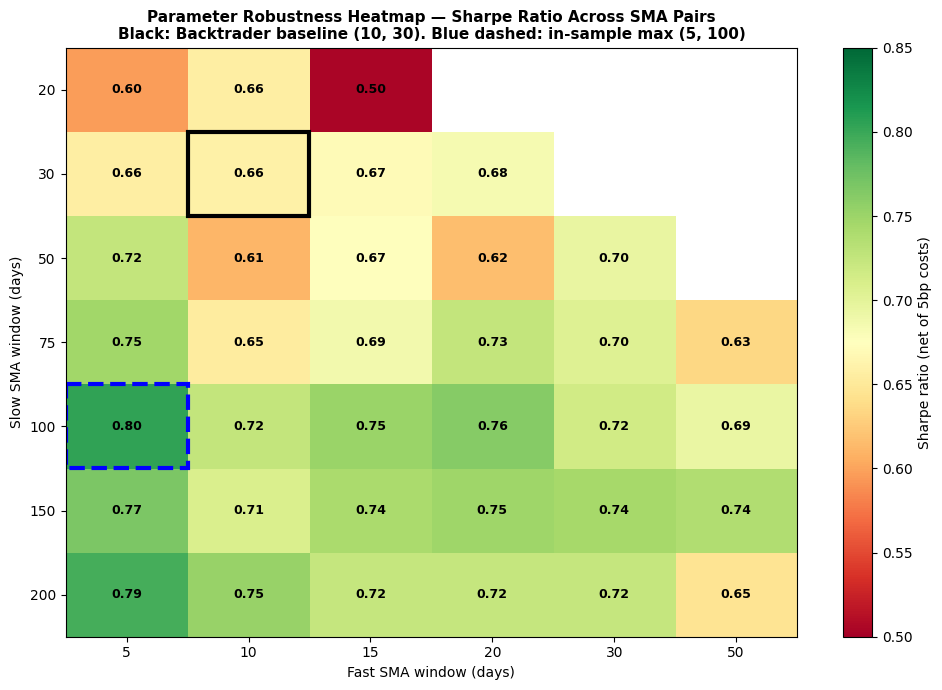

Saved to ../results/robustness_heatmap.png


In [23]:
fig, ax = plt.subplots(figsize=(10, 7))

# Plot as heatmap
im = ax.imshow(
    results_grid.values.astype(float),
    aspect="auto",
    cmap="RdYlGn",
    vmin=0.5,
    vmax=0.85,
)

plt.colorbar(im, ax=ax, label="Sharpe ratio (net of 5bp costs)")

ax.set_xticks(range(len(fast_windows)))
ax.set_xticklabels(fast_windows)
ax.set_yticks(range(len(slow_windows)))
ax.set_yticklabels(slow_windows)

# Annotate each cell
for i, slow in enumerate(slow_windows):
    for j, fast in enumerate(fast_windows):
        val = results_grid.loc[slow, fast]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2f}",
                    ha="center", va="center",
                    color="black", fontsize=9, weight="bold")

# Mark the (10, 30) baseline
fast_idx = fast_windows.index(10)
slow_idx = slow_windows.index(30)
ax.add_patch(plt.Rectangle(
    (fast_idx - 0.5, slow_idx - 0.5), 1, 1,
    fill=False, edgecolor="black", linewidth=3,
))

# Mark the (5, 100) maximum
fast_idx_max = fast_windows.index(5)
slow_idx_max = slow_windows.index(100)
ax.add_patch(plt.Rectangle(
    (fast_idx_max - 0.5, slow_idx_max - 0.5), 1, 1,
    fill=False, edgecolor="blue", linewidth=3,
    linestyle="--",
))

ax.set_xlabel("Fast SMA window (days)")
ax.set_ylabel("Slow SMA window (days)")
ax.set_title("Parameter Robustness Heatmap — Sharpe Ratio Across SMA Pairs\nBlack: Backtrader baseline (10, 30). Blue dashed: in-sample max (5, 100)",
             fontsize=11, weight="bold")

plt.tight_layout()
plt.savefig(results_dir / "robustness_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {results_dir / 'robustness_heatmap.png'}")